In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="5" color="red"><b>ch3. 분류분석</b></font>

# 1절. 분류분석 개요
    - 데이터 속성을 활용하여, 데이터에 대한 분류기준을 수립하는 과정. 타겟변수가 categorical인 분석
        ex. 고객등급예측, 휴면고객예측, 상품구매예측, 보험사기자예측....
    - sklearn 패키지
    - pip install scikit-learn
## 라이브러리의 데이터 셋의 접근
### load계열(패키지안에 데이터가 내장)
    - load_iris(), load_boston()...

### fetch 계열(패키지에 데이터가 없고, 인터넷연결하여 다운로드)
    - fetch_covtype() : 토지조사 데이터
    - fetch_20newgroups() : 뉴스텍스트 말뭉치....

### make 계열(새로운 데이터 셋 생성)
    - make_classification() : 분류분석용 가상의 데이터 생성
    - make_regression() : 회귀분석용 가상의 데이터 생성

In [3]:
# load계열(패키지내에 데이터가 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# MNIST 데이터셋 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


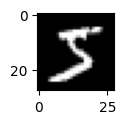

In [4]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [5]:
# fetch계열(인터넷 연결후 다운로드 c:/Users/내컴퓨터명/scikit_learn_data/openml/ 다운)
from sklearn.datasets import fetch_openml
import numpy as np
# MNIST 다운로드
mnist = fetch_openml(name='mnist_784',
                    version=1, # 데이터버전
                    as_frame=False, # False는 넘파이배열
                    parser='auto') # 파싱 방식을 sklearn이 자동결정

In [5]:
X, y = mnist.data, mnist.target.astype(np.uint8) # y는 1byte짜리 양수int
print('원 X, y :', X.shape, y.shape)
X = X.reshape(70000, 28,28)
print('reshape후 X, y :', X.shape, y.shape)

원 X, y : (70000, 784) (70000,)
reshape후 X, y : (70000, 28, 28) (70000,)


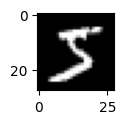

In [6]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0], cmap='gray')
plt.show()

# 2절. 분류분석의 종류
## 2.1 확률적 모형
- 주어진 데이터에 대해 각 클래스가 정답일 확률을 계산하는 모형
- **predict_proba() ; 각 분류 클래스가 될 확률들을 알려줌**(일부 판별함수모형에 있기는 함)
- **predict_log_proba() ; 확률의 로그값을 알려줌**

### 1) 확률적 생성모형
- 각 클래스별 특징 데이터의 확률분포를 추청한 다음 베이즈 정리를 사용하여 확률 계산. 소량의 데이터로도 작동하는 경우
```
    ex. sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis
        sklearn.naive_bayes.MultinomialNB
```

### 2) 확률적 판별모형
- 확률 함수를 추정하는 모형. 성능이 좋고, 해석이 쉬움
```
    ex. sklearn.linear_model.LogisticRegression
        sklearn.tree.DecisionTreeClassifier(의사결정나무) **분류에 영향을 주는 요인을 찾는데 더 많이 사용**
```

## 2.2 판별함수 모형
- 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후, 이 경계면으로부터 데이터가 어느 위치에 있는 계산하는 판별함수를 이용하는 모형
- **decision_function() : 어떤 클래스로 분류되었다를 알려줌**
```
    ex.sklearn.linear_model.Perceptron
       sklearn.svm.SVC
       sklearn.neural_network.MLPClassifier
```

=> RandomForest(배깅), XGboost, LGBM(부스팅), CatBoost등 앙상블 모형이 더 많이 사용됨

# 3절. 모형1. 확률적 생성 모형
- 베이즈 정리를 사용한 확률분포 계산
## 3.1 QDA(QuadraticDiscriminantAnalysis)
- 독립변수 X가 실수이고, 정규분포라고 가정(pdf 11p)

In [7]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(#n_samples=100, 데이터수(기본값)
                          n_features=2, # 독립변수 수
                          n_informative=2, # 독립변수 중 종속변수에 영향을 주는 변수 수
                          n_redundant=0,   # 독립변수끼리 선형관계가 있는 수(제외될 변수)
                          n_classes=2,     # 클래스 수
                          n_clusters_per_class=1, # 한 클래스당 군의 갯수
                          random_state=9,          # seed값
                          # weights=[0.5,0.5]
)
X.shape, y.shape

((100, 2), (100,))

In [8]:
# y.mean() : 0과 1 클래스가 5:5인지 확인
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [9]:
# y가 0인 독립변수 X
X[y==0][:3]

array([[-0.73358502,  0.37658657],
       [-2.25158719,  3.59851363],
       [-0.6615633 ,  0.60245197]])

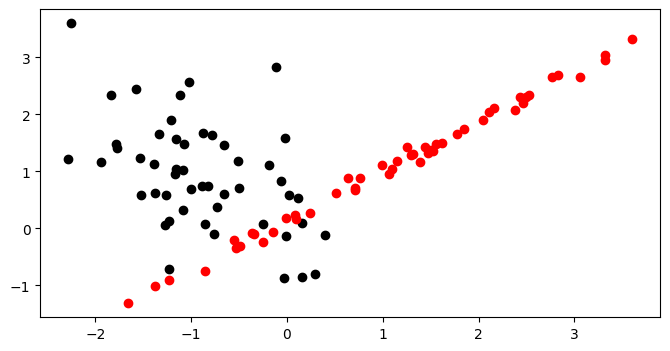

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
# y가 0인 독립변수
plt.scatter(X[y==0, 0], X[y==0, 1], c='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r')
plt.show()

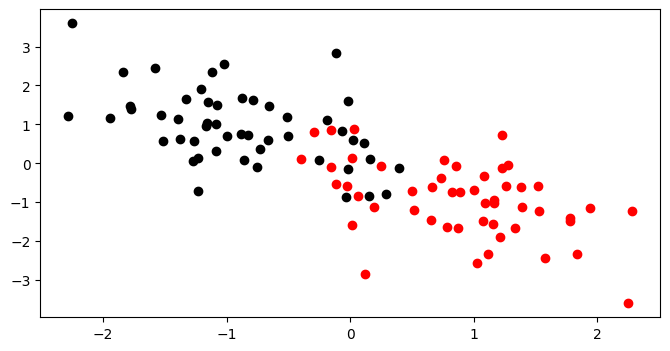

In [12]:
# 대칭구조를 만듦
X[y==1] = -X[y==0]
plt.scatter(X[y==0, 0], X[y==0, 1], c='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r')
plt.show()

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X, y)

QuadraticDiscriminantAnalysis()

In [14]:
x = [[0, -1]] # 입력데이터 2차원
p = model.predict_proba(x) # 각 class가 될 확륙
print(p) # 확률 2차원

[[0.28449825 0.71550175]]


In [15]:
model.predict(x)

array([1])

In [16]:
x = [[0, 0]] # 입력데이터 2차원
p = model.predict_proba(x) # 각 class가 될 확륙
print(p) # 확률 2차원

[[0.5 0.5]]


In [17]:
model.predict(x)

array([0])

In [18]:
# 모델의 분류
model.classes_

array([0, 1])

In [19]:
# 교차표(혼동행렬)
import pandas as pd
y_hat = model.predict(X)
pd.crosstab(y, y_hat, colnames=['예측'], rownames=['실제'], margins=True)

예측,0,1,All
실제,,,
0,44,6,50
1,6,44,50
All,50,50,100


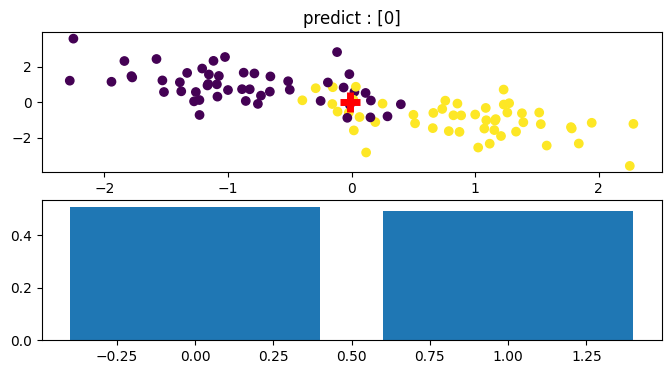

In [20]:
x = [[-0.01, 0]]
p = model.predict_proba(x)[0]
plt.subplot(211) # 2행1열로 subplot에서 첫번째 그래프
plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.scatter(x=x[0][0], y=x[0][1], c='r', s=200, marker='+', lw=5)
h = model.predict(x)
plt.title(f'predict : {h}')

plt.subplot(212)
plt.bar(model.classes_, p)
plt.show()

## 3.2 나이브베이지안 모형
- MultinomialNB

In [21]:
import seaborn as sns
iris = sns.load_dataset('iris')
# 학습데이터 : 넘파이배열
X = iris.iloc[:, :-1].to_numpy()
y = iris.iloc[:, -1].values
# 모형 생성 및 학습
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y)

MultinomialNB()

In [22]:
x = [[5.0, 3.6, 1.4, 0.2]]
h = model.predict(x) # 예측값
p = model.predict_proba(x) # 각 클래스별 확률
print('예측 :', h)
print(model.classes_)
print(p)

예측 : ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75925581 0.15640083 0.08434336]]


<BarContainer object of 3 artists>

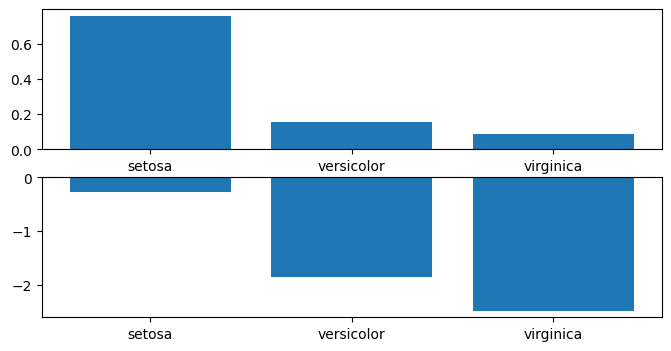

In [23]:
plt.subplot(2,1,1)
plt.bar(model.classes_, model.predict_proba(x)[0])
plt.subplot(2,1,2)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [24]:
model.score(X, y) # 모델의 정확도

0.9533333333333334

# 4절. 모형2. 확률적 판별모형
## 4.1  로지스틱 회귀모형
- 종속변수가 0/1

In [25]:
# 가상의 데이터 셋
X, y = make_classification(n_samples=100, # 데이터 갯수(행수)
                          n_features=1,   # 독립변수 갯수 (기본값20)
                          n_redundant=0,  # 제외될 독립변수 갯수(기본값2)
                          n_informative=1, # 종속변수에 영향을 주는 독립변수 갯수(기본값2)
                          n_classes=2,    # 종속변수의 클래스 수
                          n_clusters_per_class=1,  # 클래스당 군의 갯수(기본값2)
                          random_state=1)
X.shape, y.shape

((100, 1), (100,))

In [26]:
np.c_[X, y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [27]:
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [29]:
# 모형
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X, y)

In [30]:
# 모델 예측에 쓰일 x_data (2차원)
x_data = np.linspace(-3, 3, 100) # 1차원
# 2차원 데이터를 만들기 위한 축확장
x_data = x_data[:, np.newaxis]
# x_data = x_data.reshape(-1, 1)
# x_data = np.expand_dims(x_data, axis=1)
# x_data = x_data[:, None]
# x_data = np.array([[x] for x in x_data])
prob = model.predict_proba(x_data) # -3부터 3까지의 0일 확률과 1일 확률
prob[:3]

array([[9.99986168e-01, 1.38320570e-05],
       [9.99982885e-01, 1.71146738e-05],
       [9.99978824e-01, 2.11763030e-05]])

In [31]:
prob0 = prob[:, 0] # 0일 확률들
prob1 = prob[:, 1] # 1일 확률들

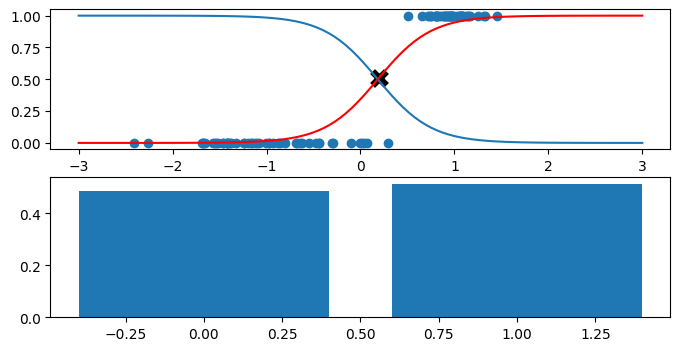

In [32]:
plt.subplot(2, 1, 1)
plt.scatter(X, y)
plt.plot(x_data, prob0)
plt.plot(x_data, prob1, c='r')

x = [[0.2]]
prob_x = model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5, s=100) # y값은 1일 확률

plt.subplot(2, 1, 2)
plt.bar(model.classes_, prob_x)
plt.show()

## 4.2 의사결정나무
- 여러가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 분류모형
- **종속변수에 영향을 주는 독립변수의 범주를 찾는 목적**
- 의사결정나무 시각화 하기 위한 라이브러리 설치

In [6]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:, 2:] # petal_length, petal_width
y = data.target
feature_names = [name[:-5] for name in data.feature_names[2:]]
X.shape, y.shape, feature_names

((150, 2), (150,), ['petal length', 'petal width'])

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion='entropy', # 트리의 분류품질기준을 entophy 값으로
                                  max_depth=1, 
                                 random_state=0)
dt_model.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [11]:
# 의사 결정 나무 분류모형의 시각화 
import io 
from sklearn.tree import export_graphviz # 모델 그래프 생성
import pydot                             # 생성된 그래프를 이미지 변환
from IPython.core.display import Image   # 이미지를 브라우저에 출력 

def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)

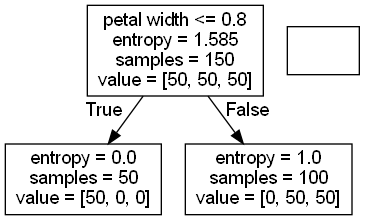

In [12]:
draw_decision_tree(dt_model, feature_names)

In [13]:
#데이터 영역을 어떻게 나누는지 시각화

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    
    Z = model.predict(
        np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
            c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
    plt.xlabel(data.feature_names[2])
    plt.ylabel(data.feature_names[3])
    plt.legend(loc='upper left')
    plt.title(title)
    return Z


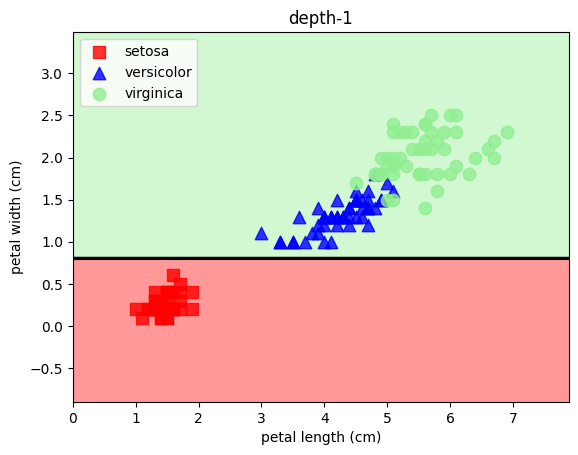

In [14]:
plot_decision_regions(X, y, dt_model, 'depth-1')
plt.show()

In [17]:
x_data =[[6, 2.5]]  #X[100]
dt_model.predict(x_data)

array([1])

In [18]:
print(dt_model.classes_)
print(dt_model.predict_proba(x_data))

[[0.  0.5 0.5]]


In [19]:
dt_model.score(X,y)

0.6666666666666666

In [23]:
dt_model5 = DecisionTreeClassifier(criterion='entropy', 
                                  max_depth=5, 
                                  random_state=0)
dt_model5.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [22]:
dt_model5.score(X,y)

0.9933333333333333

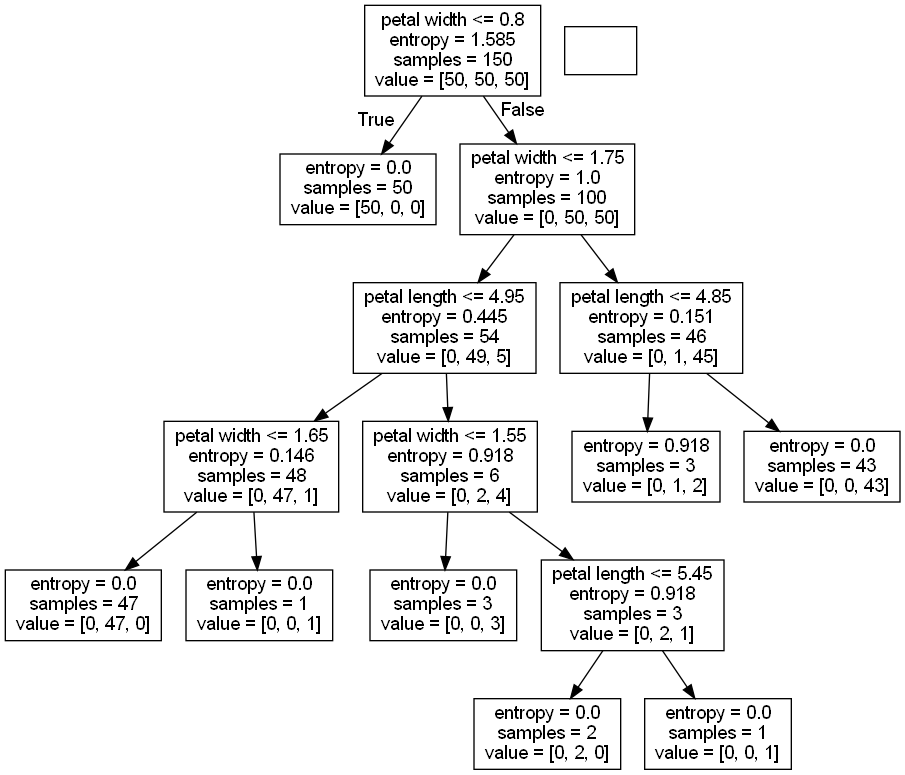

In [24]:
draw_decision_tree(dt_model5, feature_names)

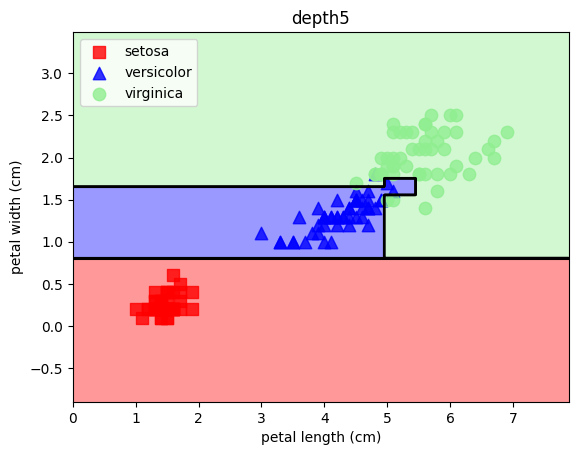

In [26]:
plot_decision_regions(X, y, dt_model5, 'depth5')
plt.show()

In [29]:
dt_model5.score(X,y)

0.9933333333333333

In [27]:
dt_model5.predict(x_data)

array([2])

In [28]:
dt_model5.predict_proba(x_data)

array([[0., 0., 1.]])

# 5절. 모형3 - 판별함수 모형
- 동일한 클래스가 모여 있는 영역과 그 외 영역을 나누는 경계면을 정의
- decision_function()함수를 제공 
- Perceptron, SVM, 다층인공신경망 모형 등이 있음(일부의 모형에서는 predict_proba()가 제공됨)

## 5.1 Perceptron

In [37]:
from sklearn.datasets import load_iris
import numpy as np 
iris = load_iris()
X=np.r_[iris.data[:50, 0:2], iris.data[100:, 0:2]] # 0~49, + 100~149qjsWoaks 
y= np.r_[iris.target[:50], iris.target[100:]]
X.shape, y.shape

((100, 2), (100,))

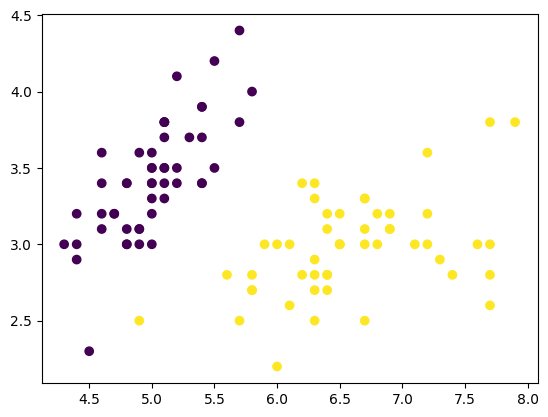

In [38]:
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y)

In [41]:
# 퍼셉트론 모형 
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=100, #epoch
                   eta0=0.1,       #learning rate
                   random_state =1).fit(X,y)

In [44]:
y_pred = model.predict(X)
y.sum()

100

In [45]:
import pandas as pd 
y_pres = model.predict(X)
pd.crosstab(y, y_pred, rownames=['true'], colnames=['pred'], margins=True)

pred,0,2,All
true,,,
0,49,1,50
2,0,50,50
All,49,51,100


In [49]:
# 잘못 예측한 값 찾아보기 
y_pred
for idx, (real, pred) in enumerate(zip(y, y_pred)):
    #print(idx, real, pred)
    if real!= pred:
        print(f'{idx}번째 실제값:{real}, 예측값:{pred}-데이터 : {X[idx]}')

41번째 실제값:0, 예측값:2-데이터 : [4.5 2.3]


In [52]:
x_data =[[4.5, 2.3]]
print('예측:', model.predict(x_data))
print(model.decision_function(x_data))
# decision_function(x) 결과 양수:2
#decision_function(x) 결과 음수: 0

예측: [2]
[1.24]


In [55]:
X[0][np.newaxis, :] # X[0].reshape(1,-1), np.expand_dims(X[0], axis=0)
print('예측:', model.predict(x_data))
print(model.decision_function(x_data))

예측: [2]
[1.24]


## 5.2 SVC
- Support Vector Classifier

In [62]:
from sklearn.svm import  SVC
model = SVC(
    probability = True 
    )
model.fit(X, y)

SVC(probability=True)

In [64]:
x_data = [[4.5, 2.3]]
print(model.predict(x_data))
print(model.decision_function(x_data)) #음수면 0 / 양수면 1
print(model.predict_proba(x_data))  # 판별함수모형

[0]
[-0.72539221]
[[0.89497839 0.10502161]]


## 5.3 다중퍼셉트론(다층인공신경망)
- predict / predict_proba / decision_function 모두 가능

In [68]:
from sklearn.neural_network import MLPClassifier
mlp= MLPClassifier(hidden_layer_sizes=(50, 50, 50),
                   max_iter=500 #학습횟수가 작으면 경고가 출력되기도 함 
                  )
mlp.fit(X, y)

MLPClassifier(hidden_layer_sizes=(50, 50, 50), max_iter=500)

In [70]:
pred = mlp.predict(X)
pd.crosstab(y, pred)

col_0,0,2
row_0,,
0,50,0
2,0,50


# 6절. 분류모형 성능평가
## 6.1 sklearn-learn의 모형평가 방법
- 에측 모형에 score 메서드
    * 예측 모형의 score(test_X, test_y) 함수가 기본 제공(분류모형의 경우 accuracy, 회귀모형의 경우 r2 결정계수, 군집분석은 score없음)
- metrics 패키지 함수 
    * accuracy, recall, precision, 특이도, 위양성율(fp rate), f-1score, f-beta score, ... roc 커브, 
- scoring 매개변수 
    * GridSearchCV 클래스를 이용한 교차검증 분석도구 => ch4.2 

## 6.2 혼돈행렬을 이용한 평가 
- accuracy, recall, precision, 특이도, 위양성율(fp rate), f-1score, f-beta score

In [71]:
import pandas as pd 
result = pd.read_csv('data/model_result.csv') #보험 사기자 실제값과 예측값
result.head()

,CUST_ID,y_true,y_pred
0,37,0,0
1,51,0,0
2,60,0,0
3,65,0,0
4,73,0,0


In [72]:
result.isna().sum() # 결측치 갯수 

CUST_ID    0
y_true     0
y_pred     0
dtype: int64

In [82]:
# 보험사기자 여부 0:1의 비율 
print('전체데이터 수 :', result.shape[0])
print('N0:P1 빈도 :\n', result.y_true.value_counts())
print('N0:P1 비율 :\n', result.y_true.value_counts(normalize=True))

전체데이터 수 : 1793
N0:P1 빈도 :
 0    1635
1     158
Name: y_true, dtype: int64
N0:P1 비율 :
 0    0.91188
1    0.08812
Name: y_true, dtype: float64


In [75]:
# 혼돈행렬
pd.crosstab(result.y_true, result.y_pred, margins=True)

y_pred,0,1,All
y_true,,,
0,1613,22,1635
1,81,77,158
All,1694,99,1793


In [81]:
#혼돈행렬
from sklearn.metrics import confusion_matrix
confusion_matrix(result.y_true, result.y_pred)

array([[1613,   22],
       [  81,   77]], dtype=int64)

In [83]:
# 이진 분류에서의 accuracy, precision, recall 
from sklearn.metrics import accuracy_score, precision_score, recall_score
print('정확도(accuracy):', precision_score(result.y_true, result.y_pred))
print('정밀도(precision):', accuracy_score(result.y_true, result.y_pred))
print('재현율(recall):', recall_score(result.y_true, result.y_pred))

정확도(accuracy): 0.7777777777777778
정밀도(precision): 0.9425543781372002
재현율(recall): 0.4873417721518987


In [ ]:
# 다중분류에서의 precision, recall 
#average=binary (기본값; 이진분류), 
#         # macro(클래스별 샘플수를 가중치로 곱하여 평균계산),
#         # weighted (클래스별 불균형이 심할 때의 평균 계산)
# print('정밀도(precision):', accuracy_score(result.y_true, result.y_pred, average='macro'))
# print('재현율(recall):', recall_score(result.y_true, result.y_pred))

In [84]:
# f1 score (precision과 recall의 조화평균) = 2* (recall * precision) / (precision +recall )
from sklearn.metrics import f1_score, fbeta_score
print('f1 score:', f1_score(result.y_true, result.y_pred))

f1 score: 0.5992217898832685


In [88]:
# f beta score = (1+ beta제곱) * (recall * precision) / (beta제곱 * precision +recall)
# precision 의 가중치가 높음 (고객의 만족도 우선): beta가 1미만 
print(fbeta_score(result.y_true, result.y_pred, beta=0.5))
# recall의 가중치가 높음 (회사의 비용 중시) : beta가 1 초과 
print(fbeta_score(result.y_true, result.y_pred, beta=1.5))
#precision과 recall의 가중치를 같게 : beta가 1 == f1_score
print(fbeta_score(result.y_true, result.y_pred, beta=1))

0.6949458483754513
0.5506050605060505
0.5992217898832685


In [91]:
# 특이도 : 0이라고 제대로 예측한 수 / 실제 0인 수 
spec = recall_score (result.y_true, result.y_pred, pos_label=0)

In [92]:
# 위양성률(fp rate=1종오류, 오탐)
1- spec

0.013455657492354778

## 6.3 ROC 커브를 이용한 성능 비교 
- ROC 커브 : 클래스 판별 기준값의 변화에 따른 위양성률(fall-out; fp_rate)와 재현율(recall; tp_rate)의 변화를 시각화
- 세로축 : TPRate(재현율) 
- 가로축 : FPRate(위양성율) 

In [98]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples =100, #데이터 행수
                          n_features=2,    #독립변수 갯수
                          n_informative=2, #종속변수에 영향을 주는 독립변수 갯수
                          n_redundant=0, # 제외될 독립변수 갯수 
                          n_classes=2,  #종속변수의 class수(0/1)
                          random_state=0
                          )
X.shape, y.shape

((100, 2), (100,))

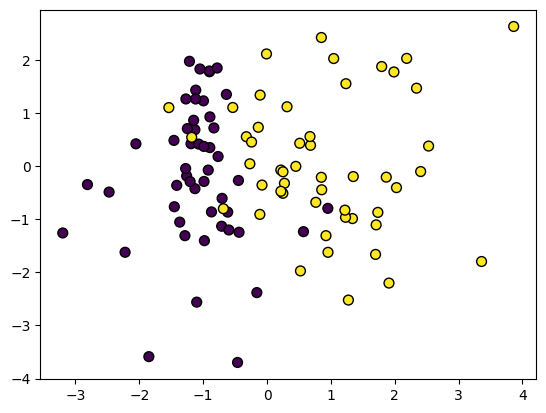

In [99]:
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:,1], c=y, edgecolors='k', s=50)
plt.show()

In [100]:
from sklearn.svm import SVC 
model = SVC(probability=True)
model.fit(X,y) 

SVC(probability=True)

In [ ]:
y_pred = model.predict(X) 

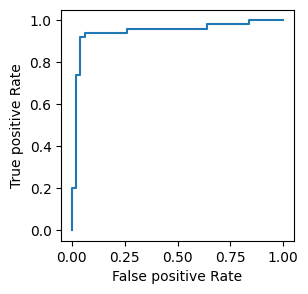

In [105]:
# roc_curve() 함수를 이용하여 fprate과 tprate값을 도출 
    # roc_curve(y, model.decision_function(X))
    # roc_curve(y, model.predict_proba(X)[:,1])
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, model.decision_function(X))
fpr1, tpr1,thresholds = roc_curve(y, model.predict_proba(X)[:,1])
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, c='b')
plt.plot(fpr1, tpr1, c='r', alpha=0.5)
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.show()

## 6.4 두 모형의 혼돈 행렬이 같을 경우 (roc_curve 사용)

In [115]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, 
                          weights=[0.95, 0.05], # 0이 95%, 1이 5%
                          n_classes=2, 
                          random_state=5)
X.shape, y.shape

((1000, 20), (1000,))

In [116]:
np.unique(y, return_counts=True)

(array([0, 1]), array([943,  57], dtype=int64))

In [121]:
from sklearn.linear_model import LogisticRegression 
model1=LogisticRegression().fit(X,y)

In [122]:
model2 = SVC(gamma=0.0001, # 작을 수록 결정경계이 곡률이 부드러운 경계. 클수록 구불구불한 경계
             C=3000, 
            probability=True).fit(X, y)

In [136]:
from sklearn.tree import DecisionTreeClassifier
model3 = DecisionTreeClassifier(random_state=42).fit(X, y)

In [137]:
# 두 모델의 예측값 
pred1 = model1.predict(X)
pred2 = model2.predict(X)
pred3 = model3.predict(X) 

In [124]:
# 두 모델의 혼돈행렬 같음 : model1
confusion_matrix(y, pred1)

array([[940,   3],
       [ 30,  27]], dtype=int64)

In [125]:
confusion_matrix(y, pred2) #model2

array([[940,   3],
       [ 30,  27]], dtype=int64)

In [138]:
confusion_matrix(y, pred3) #model3

array([[943,   0],
       [  0,  57]], dtype=int64)

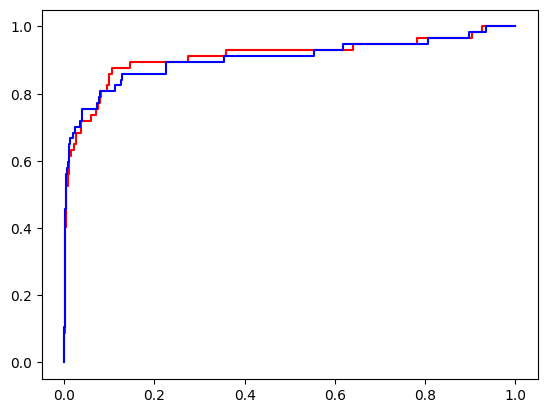

In [139]:
# roc curve 
fpr1, tpr1, th1 = roc_curve(y, model1.predict_proba(X)[:, 1])
fpr2, tpr2, th2 = roc_curve(y, model2.predict_proba(X)[:, 1])
fpr3, tpr3, th3 = roc_curve(y, model3.predict_proba(X)[:, 1])
plt.plot(fpr1, tpr1, c='r')
plt.plot(fpr2, tpr2, c='b')
plt.show()

In [143]:
# AUC (Area Under Curve) : roc_curve 아래면적 
from sklearn.metrics import auc
auc(fpr1, tpr1), auc(fpr2, tpr2), auc(fpr3, tpr3)

(0.9112202563673234, 0.9037227214377407, 1.0)